# DLA Error Budget — Visual Analysis

Plots for the DLA vs Direct Effect (DE) vs Activation Patching (AP) comparison
across **three models** and **two ablation modes** (zero, mean).

| Metric | Definition | Denominator |
|--------|-----------|-------------|
| **Source A** | NMAE(DLA, DE) | Σ\|AP\| |
| **Source B** | NMAE(DE, AP) | Σ\|AP\| |
| **Total** | NMAE(DLA, AP) | Σ\|AP\| |

Data produced by `experiments/stereoset/dla_error_analysis.py`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

OUTPUT_DIR = Path("../../outputs/dla_error_analysis")

with open(OUTPUT_DIR / "summary_all_models.json") as f:
    summary_list = json.load(f)
summary_df = pd.DataFrame(summary_list)

record_dfs = {}
for _, row in summary_df.iterrows():
    safe = row["model"].replace("/", "_")
    mode = row["ablation_type"]
    path = OUTPUT_DIR / f"{safe}_{mode}_ablation_records.csv"
    if path.exists():
        record_dfs[(row["model"], mode)] = pd.read_csv(path)

MODELS = summary_df["model"].unique()


def nmae_against(a, b, denom_source):
    denom = np.sum(np.abs(denom_source))
    return float(np.sum(np.abs(a - b)) / denom * 100.0) if denom else float("inf")


print(f"Summary rows     : {len(summary_df)}")
print(f"Record DFs loaded: {len(record_dfs)}")
summary_df[["model", "ablation_type", "n_records", "n_examples",
            "source_a_frozen_norm_nmae", "source_b_indirect_effect_nmae",
            "total_dla_error_nmae"]]

Summary rows     : 6
Record DFs loaded: 6


,model,ablation_type,n_records,n_examples,source_a_frozen_norm_nmae,source_b_indirect_effect_nmae,total_dla_error_nmae
0,gpt2-xl,zero,374400,100,41.67,104.61,110.96
1,gpt2-xl,mean,374400,100,77.35,96.27,135.01
2,meta-llama/Llama-3.2-1B,zero,158400,100,17.38,95.24,101.15
3,meta-llama/Llama-3.2-1B,mean,158400,100,90.26,97.58,150.26
4,google/gemma-2-2b,zero,70200,100,15.28,101.84,101.36
5,google/gemma-2-2b,mean,70200,100,67.55,100.92,140.76


## 1. Headline NMAE — Error Budget (all models, both ablation modes)

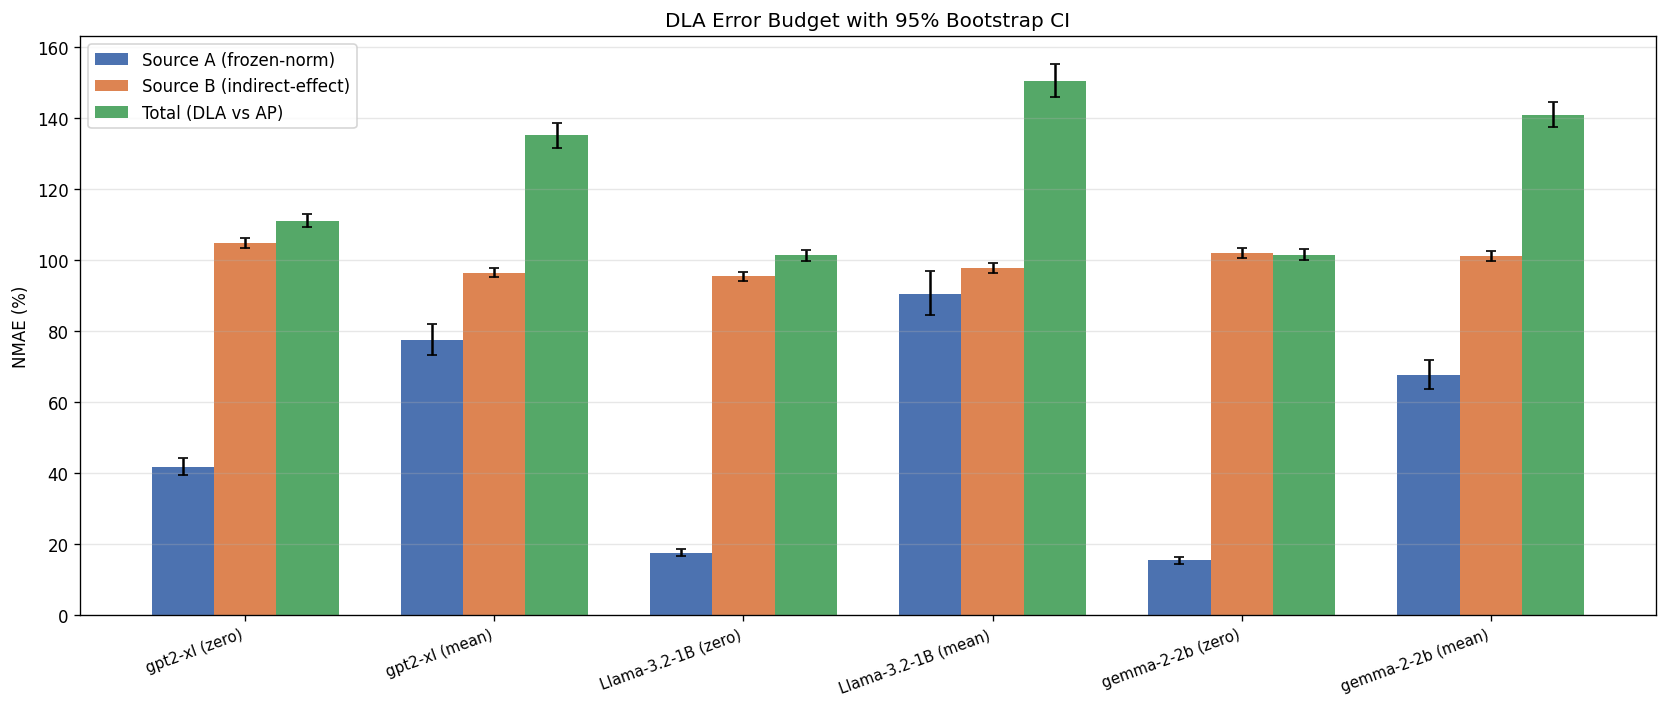

In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

labels = [f"{r['model'].split('/')[-1]} ({r['ablation_type']})"
          for _, r in summary_df.iterrows()]
x = np.arange(len(labels))
w = 0.25

metrics = [
    ("source_a_frozen_norm_nmae", "source_a_ci_lo", "source_a_ci_hi",
     "Source A (frozen-norm)"),
    ("source_b_indirect_effect_nmae", "source_b_ci_lo", "source_b_ci_hi",
     "Source B (indirect-effect)"),
    ("total_dla_error_nmae", "total_ci_lo", "total_ci_hi",
     "Total (DLA vs AP)"),
]

colors = ["#4C72B0", "#DD8452", "#55A868"]
for i, (col, lo_col, hi_col, label) in enumerate(metrics):
    vals = summary_df[col].values
    lo = vals - summary_df[lo_col].values
    hi = summary_df[hi_col].values - vals
    ax.bar(x + i * w, vals, w, yerr=[lo, hi], capsize=3,
           label=label, color=colors[i])

ax.set_xticks(x + w)
ax.set_xticklabels(labels, fontsize=9, rotation=20, ha="right")
ax.set_ylabel("NMAE (%)")
ax.set_title("DLA Error Budget with 95% Bootstrap CI")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Zero vs Mean Ablation — Side-by-Side Comparison

How does switching from zero- to mean-ablation affect each error source?

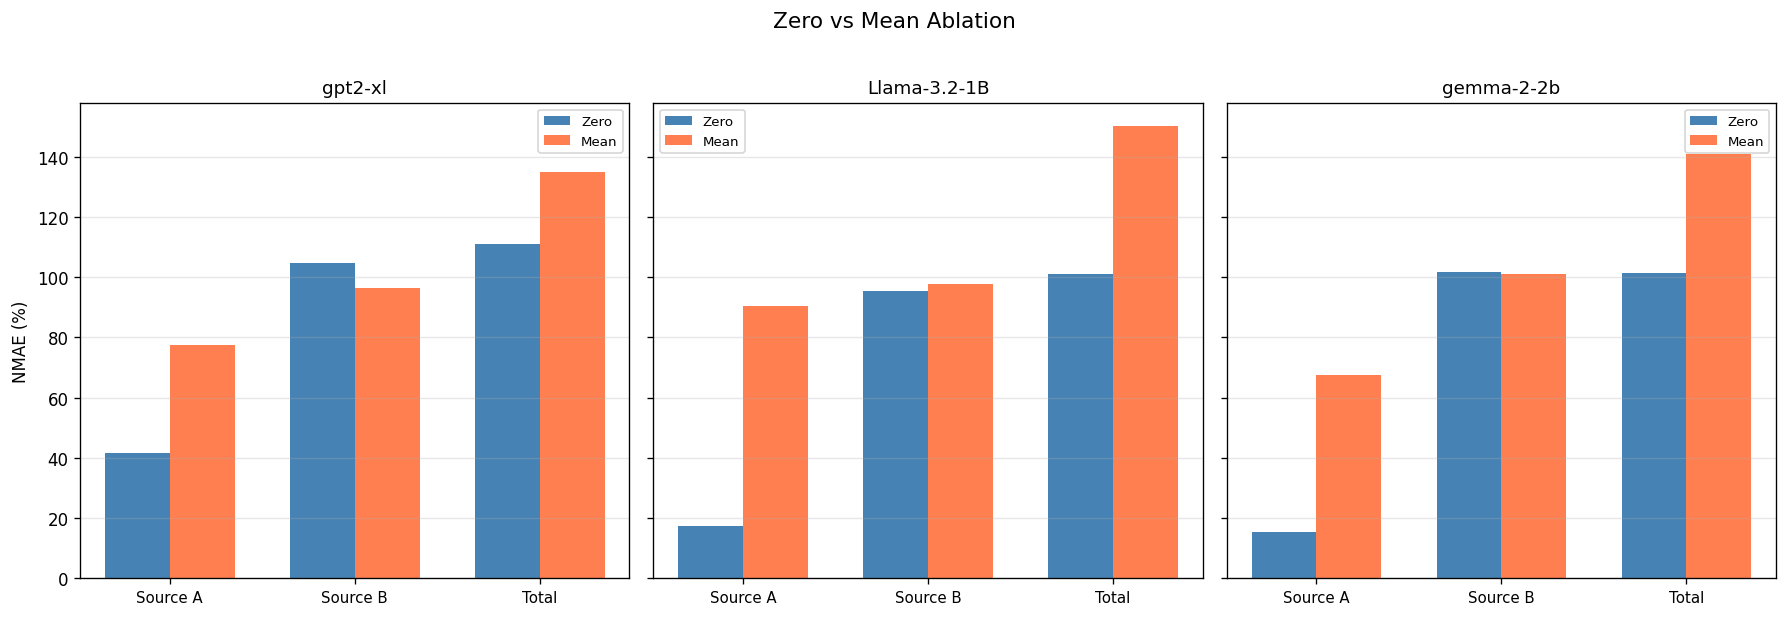

In [3]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5),
                         sharey=True)
if len(MODELS) == 1:
    axes = [axes]

metric_cols = ["source_a_frozen_norm_nmae",
               "source_b_indirect_effect_nmae",
               "total_dla_error_nmae"]
short_labels = ["Source A", "Source B", "Total"]

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    sub = summary_df[summary_df["model"] == model]
    zero_row = sub[sub["ablation_type"] == "zero"].iloc[0]
    mean_row = sub[sub["ablation_type"] == "mean"].iloc[0]

    xp = np.arange(len(metric_cols))
    w = 0.35
    ax.bar(xp - w / 2, [zero_row[m] for m in metric_cols], w,
           label="Zero", color="steelblue")
    ax.bar(xp + w / 2, [mean_row[m] for m in metric_cols], w,
           label="Mean", color="coral")
    ax.set_xticks(xp)
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_title(model.split("/")[-1], fontsize=11)
    if idx == 0:
        ax.set_ylabel("NMAE (%)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Zero vs Mean Ablation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Selection Quality — Spearman, Sign Agreement, Top-k Jaccard

DLA's usefulness for component *selection* depends on ranking correlation with AP, not just NMAE.

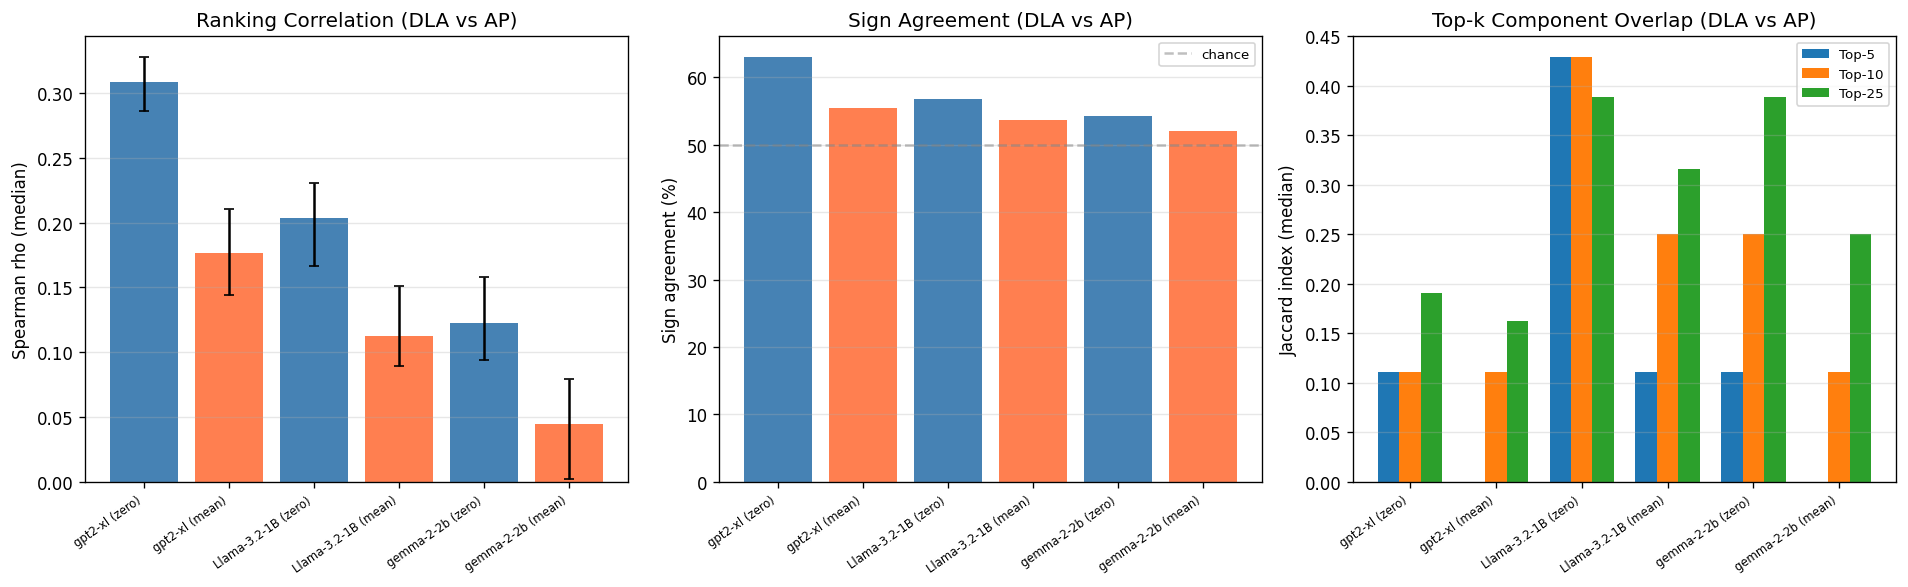

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels = [f"{r['model'].split('/')[-1]} ({r['ablation_type']})"
          for _, r in summary_df.iterrows()]
colors = ["steelblue" if r["ablation_type"] == "zero" else "coral"
          for _, r in summary_df.iterrows()]
x = np.arange(len(labels))

# -- Spearman rho --
ax = axes[0]
vals = summary_df["spearman_median"].values
iqr_lo = np.array([r["spearman_iqr"][0] for _, r in summary_df.iterrows()])
iqr_hi = np.array([r["spearman_iqr"][1] for _, r in summary_df.iterrows()])
ax.bar(x, vals, yerr=[vals - iqr_lo, iqr_hi - vals], capsize=3, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7, rotation=35, ha="right")
ax.set_ylabel("Spearman rho (median)")
ax.set_title("Ranking Correlation (DLA vs AP)")
ax.grid(axis="y", alpha=0.3)

# -- Sign agreement --
ax = axes[1]
vals = summary_df["sign_agreement"].values * 100
ax.bar(x, vals, color=colors)
ax.axhline(50, color="gray", ls="--", alpha=0.5, label="chance")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7, rotation=35, ha="right")
ax.set_ylabel("Sign agreement (%)")
ax.set_title("Sign Agreement (DLA vs AP)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# -- Top-k Jaccard --
ax = axes[2]
w = 0.25
for i, k in enumerate([5, 10, 25]):
    col = f"top{k}_jaccard_median"
    ax.bar(x + i * w, summary_df[col].values, w, label=f"Top-{k}")
ax.set_xticks(x + w)
ax.set_xticklabels(labels, fontsize=7, rotation=35, ha="right")
ax.set_ylabel("Jaccard index (median)")
ax.set_title("Top-k Component Overlap (DLA vs AP)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Frozen-Norm Identity Check

The closed-form identity **DE(c) = clean·(1−ρ) + ρ·DLA(c)** holds exactly for zero-ablation
(residual ≈ 0) and breaks for mean-ablation (large residual).

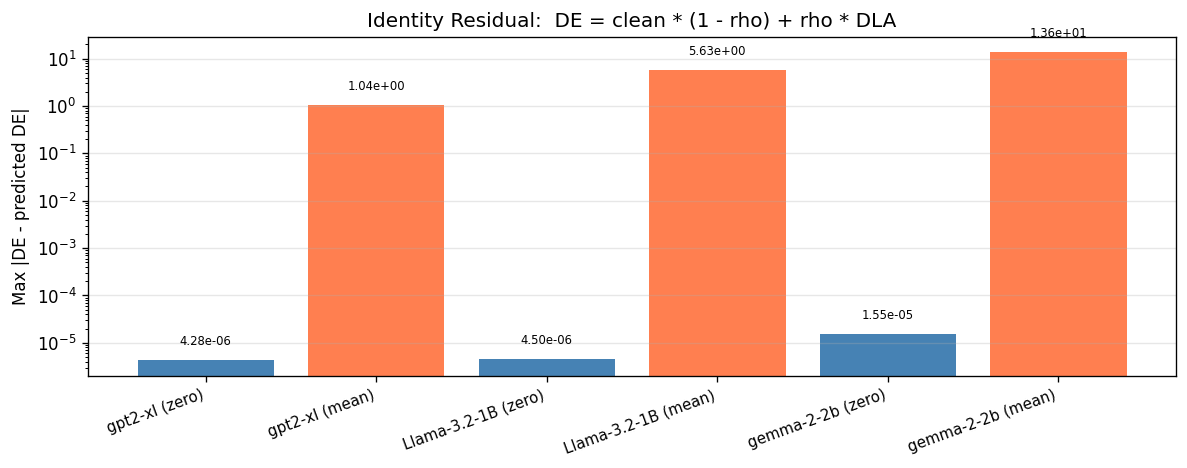

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

labels = [f"{r['model'].split('/')[-1]} ({r['ablation_type']})"
          for _, r in summary_df.iterrows()]
vals = summary_df["frozen_norm_identity_max_residual"].values
colors = ["steelblue" if r["ablation_type"] == "zero" else "coral"
          for _, r in summary_df.iterrows()]

bars = ax.bar(range(len(vals)), vals, color=colors)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, fontsize=9, rotation=20, ha="right")
ax.set_ylabel("Max |DE - predicted DE|")
ax.set_title("Identity Residual:  DE = clean * (1 - rho) + rho * DLA")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.8,
            f"{val:.2e}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## 5. Soft-Cap Distortion (Gemma-2 only)

The `tanh(logits/30)` soft-capping distorts both DE and AP relative to their pre-cap values.

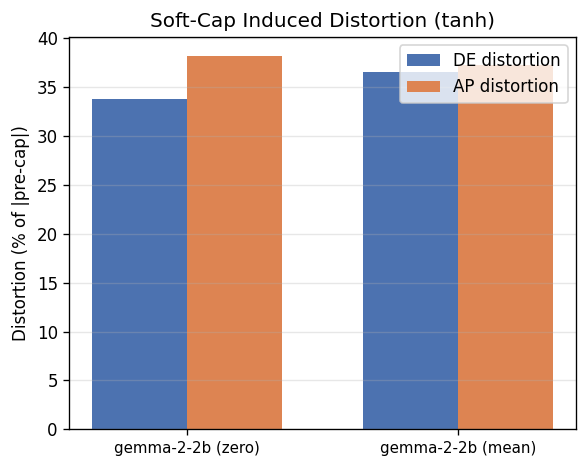

In [6]:
cap_col = "cap_distortion_de_pct_of_precap"
cap_rows = (summary_df.dropna(subset=[cap_col])
            if cap_col in summary_df.columns else pd.DataFrame())

if len(cap_rows):
    fig, ax = plt.subplots(figsize=(max(5, 2.5 * len(cap_rows)), 4))
    labels = [f"{r['model'].split('/')[-1]} ({r['ablation_type']})"
              for _, r in cap_rows.iterrows()]
    xp = np.arange(len(cap_rows))
    w = 0.35
    ax.bar(xp - w / 2,
           cap_rows["cap_distortion_de_pct_of_precap"].values,
           w, label="DE distortion", color="#4C72B0")
    ax.bar(xp + w / 2,
           cap_rows["cap_distortion_ap_pct_of_precap"].values,
           w, label="AP distortion", color="#DD8452")
    ax.set_xticks(xp)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Distortion (% of |pre-cap|)")
    ax.set_title("Soft-Cap Induced Distortion (tanh)")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No models with soft-cap distortion data.")

## 6. Frozen-Norm Ratio (ρ) Distribution

ρ = scale(r) / scale(r−c) measures how much removing component *c* changes
the residual stream's norm. When ρ ≈ 1, DLA ≈ DE. The deviation from 1
is what drives Source A error.

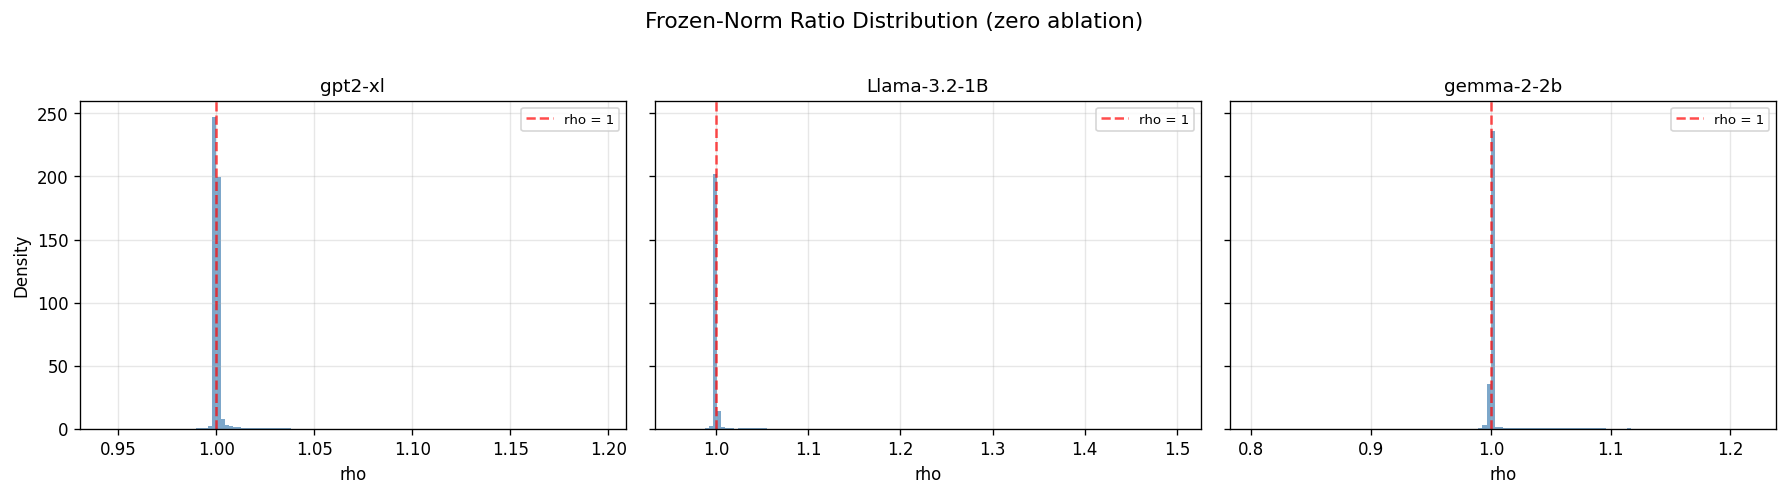

In [7]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 4),
                         sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    key = (model, "zero")
    if key not in record_dfs or "rho" not in record_dfs[key].columns:
        continue
    rho = record_dfs[key]["rho"].values
    ax.hist(rho, bins=120, alpha=0.7, color="steelblue", density=True)
    ax.axvline(1.0, color="red", ls="--", alpha=0.7, label="rho = 1")
    ax.set_xlabel("rho")
    if idx == 0:
        ax.set_ylabel("Density")
    ax.set_title(model.split("/")[-1], fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Frozen-Norm Ratio Distribution (zero ablation)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Per-Layer NMAE Breakdown

Does the frozen-norm / indirect-effect error grow with depth?

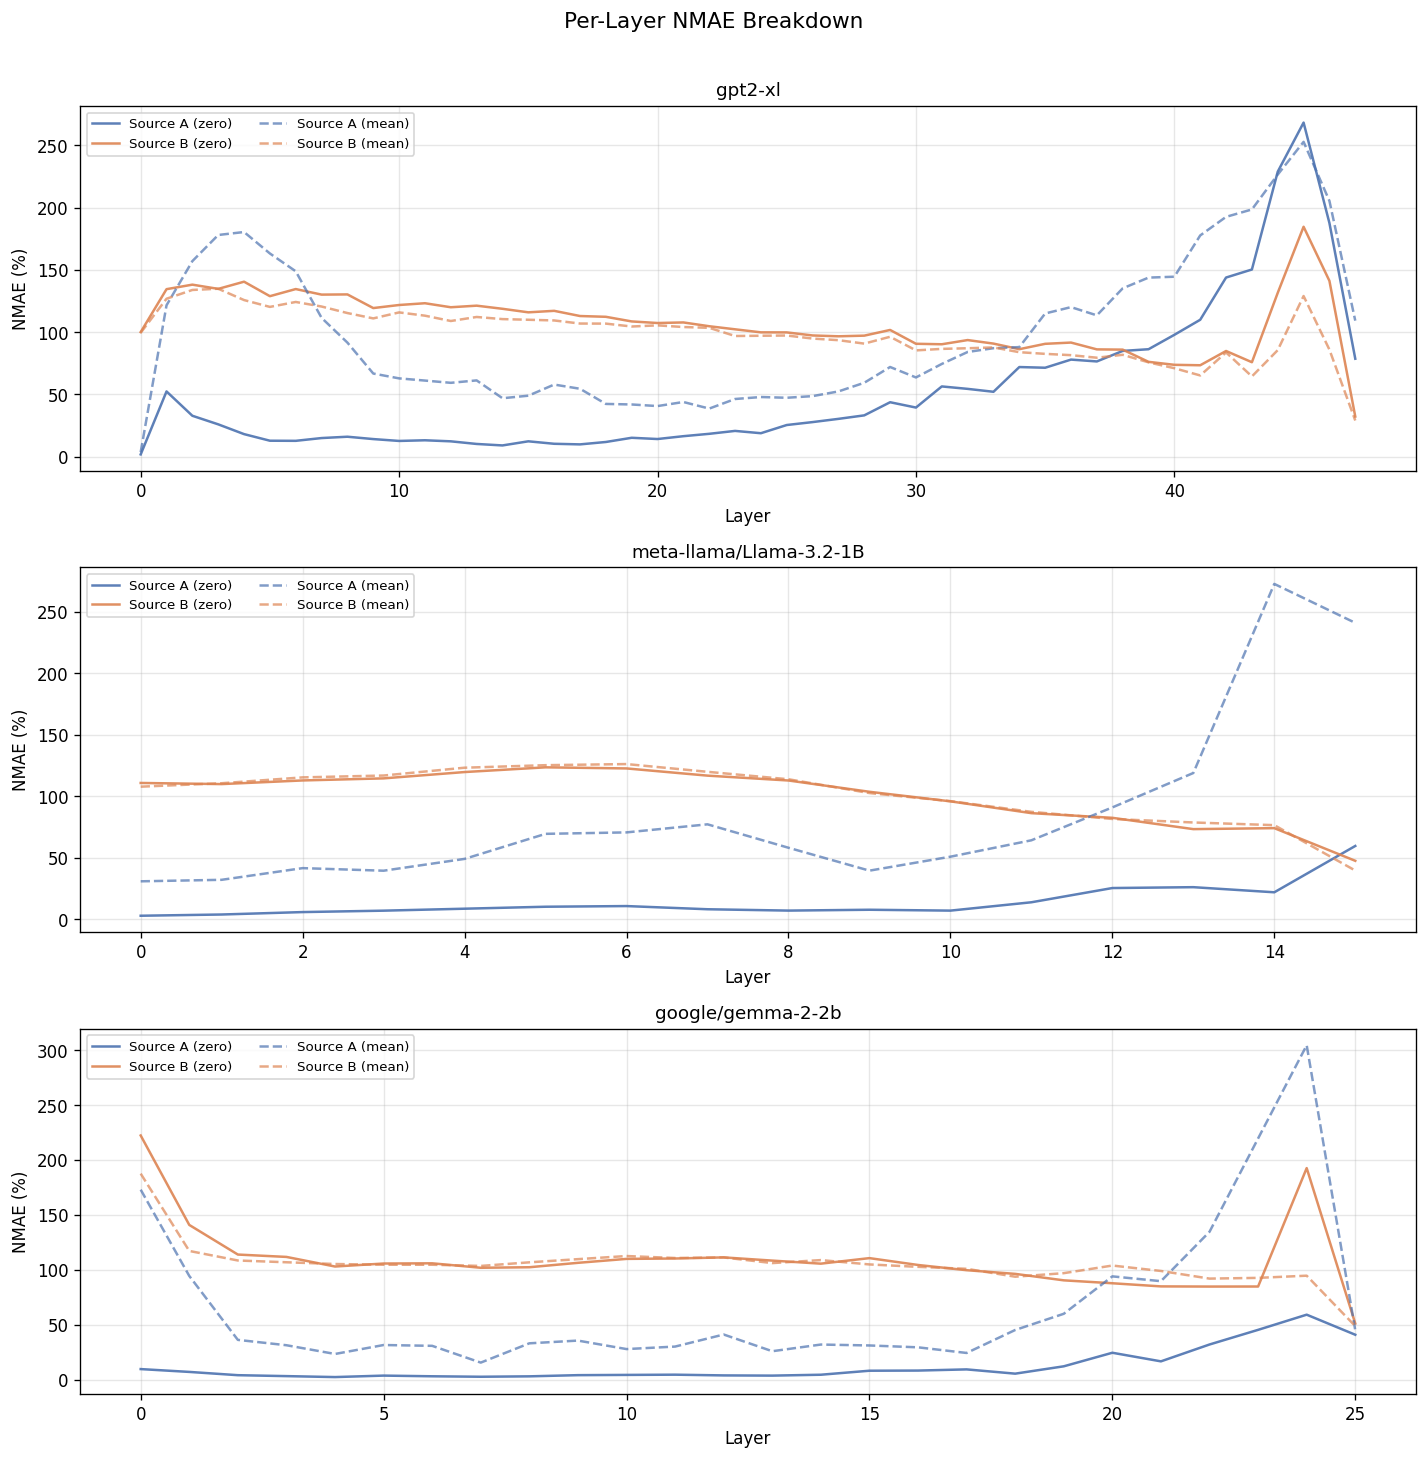

In [8]:
fig, axes = plt.subplots(len(MODELS), 1, figsize=(12, 4 * len(MODELS)))
if len(MODELS) == 1:
    axes = [axes]

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    for mode, ls, alpha in [("zero", "-", 0.9), ("mean", "--", 0.7)]:
        key = (model, mode)
        if key not in record_dfs:
            continue
        df = record_dfs[key]
        layers = sorted(df["layer"].unique())
        sa_layer, sb_layer = [], []
        for layer in layers:
            sub = df[df["layer"] == layer]
            dla = sub["dla"].values
            de = sub["de_precap"].values
            ap = sub["ap_precap"].values
            sa_layer.append(nmae_against(dla, de, ap))
            sb_layer.append(nmae_against(de, ap, ap))
        ax.plot(layers, sa_layer, ls, label=f"Source A ({mode})",
                alpha=alpha, color="#4C72B0")
        ax.plot(layers, sb_layer, ls, label=f"Source B ({mode})",
                alpha=alpha, color="#DD8452")
    ax.set_title(model, fontsize=11)
    ax.set_xlabel("Layer")
    ax.set_ylabel("NMAE (%)")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

fig.suptitle("Per-Layer NMAE Breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Component Type Breakdown — Heads vs MLPs

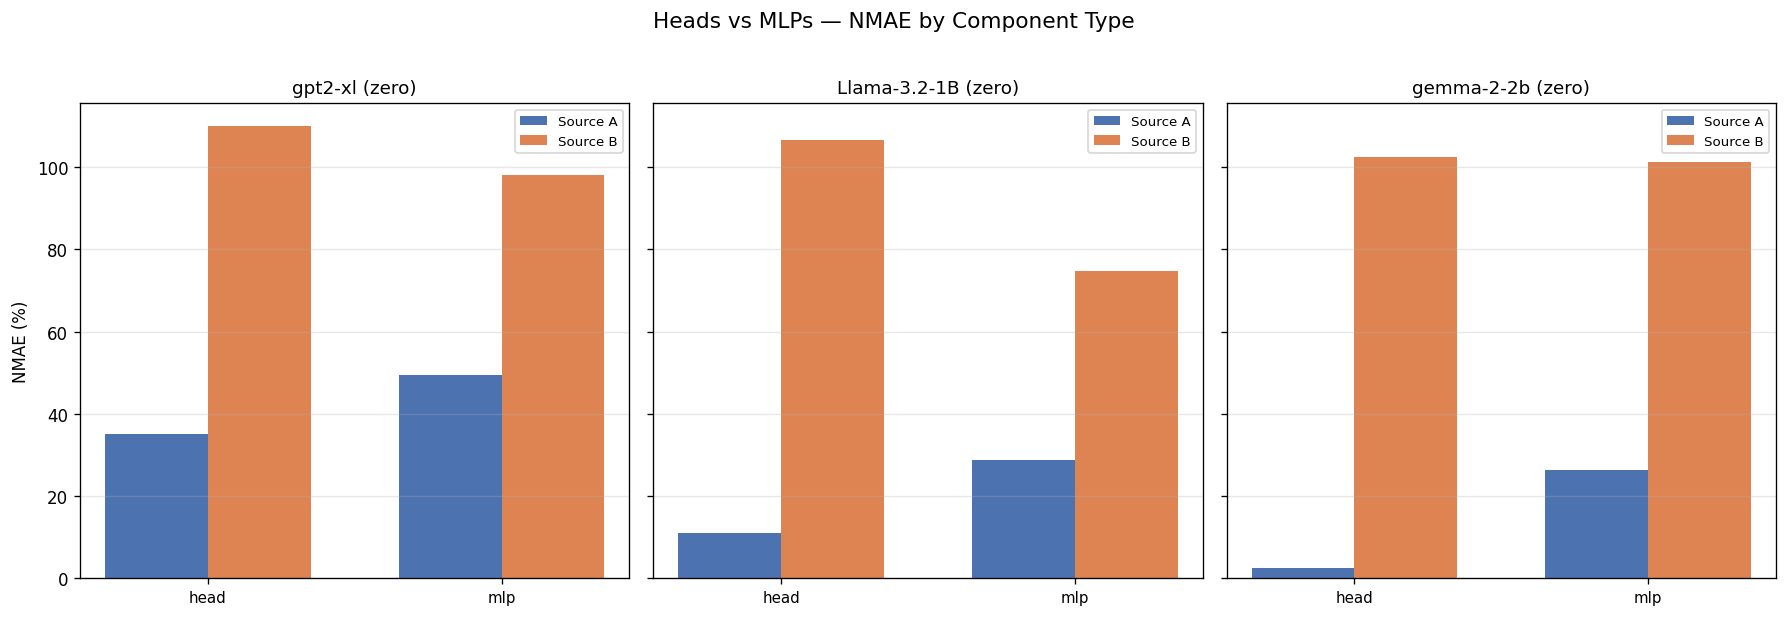

In [9]:
fig, axes = plt.subplots(1, len(MODELS),
                         figsize=(5 * len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for idx, model in enumerate(MODELS):
    ax = axes[idx]
    key = (model, "zero")
    if key not in record_dfs:
        continue
    df = record_dfs[key]
    comp_types = sorted(df["component_type"].unique())
    sa_vals, sb_vals = [], []
    for ct in comp_types:
        sub = df[df["component_type"] == ct]
        dla = sub["dla"].values
        de = sub["de_precap"].values
        ap = sub["ap_precap"].values
        sa_vals.append(nmae_against(dla, de, ap))
        sb_vals.append(nmae_against(de, ap, ap))
    xp = np.arange(len(comp_types))
    w = 0.35
    ax.bar(xp - w / 2, sa_vals, w, label="Source A", color="#4C72B0")
    ax.bar(xp + w / 2, sb_vals, w, label="Source B", color="#DD8452")
    ax.set_xticks(xp)
    ax.set_xticklabels(comp_types, fontsize=9)
    ax.set_title(f"{model.split('/')[-1]} (zero)", fontsize=11)
    if idx == 0:
        ax.set_ylabel("NMAE (%)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Heads vs MLPs — NMAE by Component Type",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Agreement Scatter Plots

DLA vs DE, DE vs AP, DLA vs AP — subsampled to 10 000 points for readability.

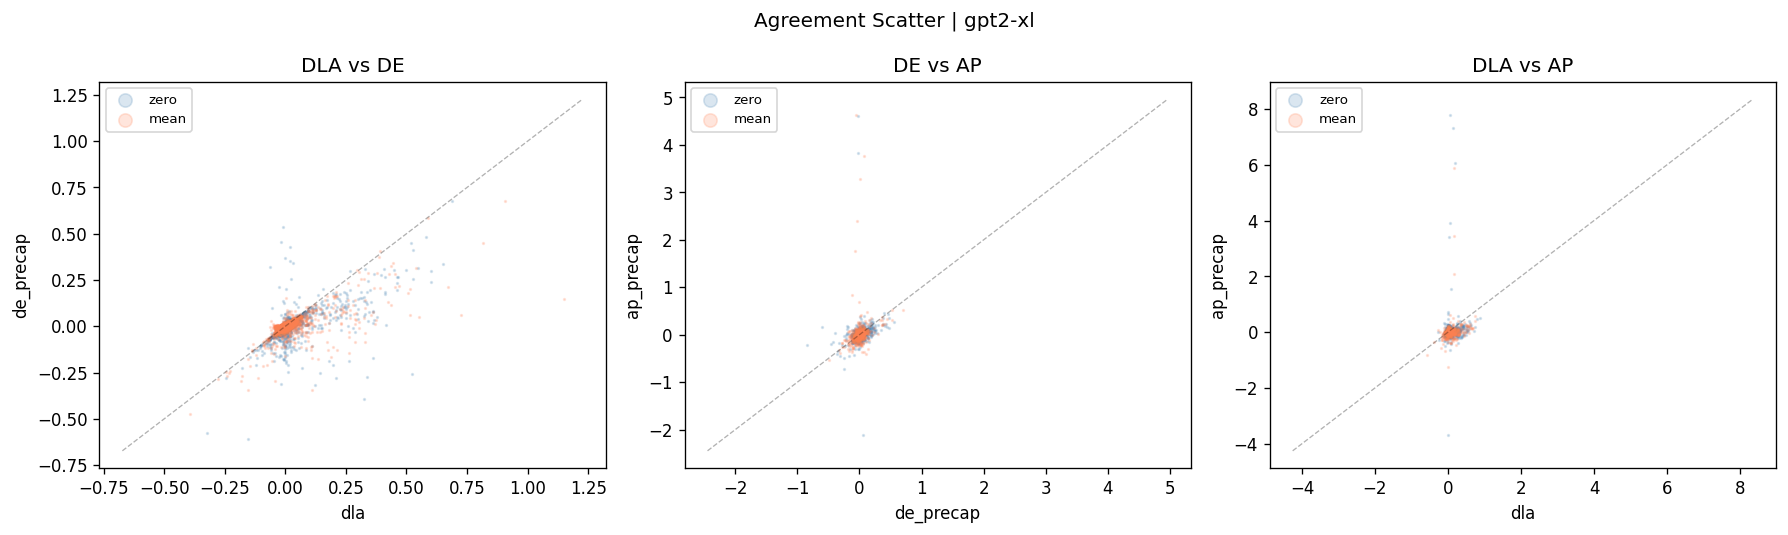

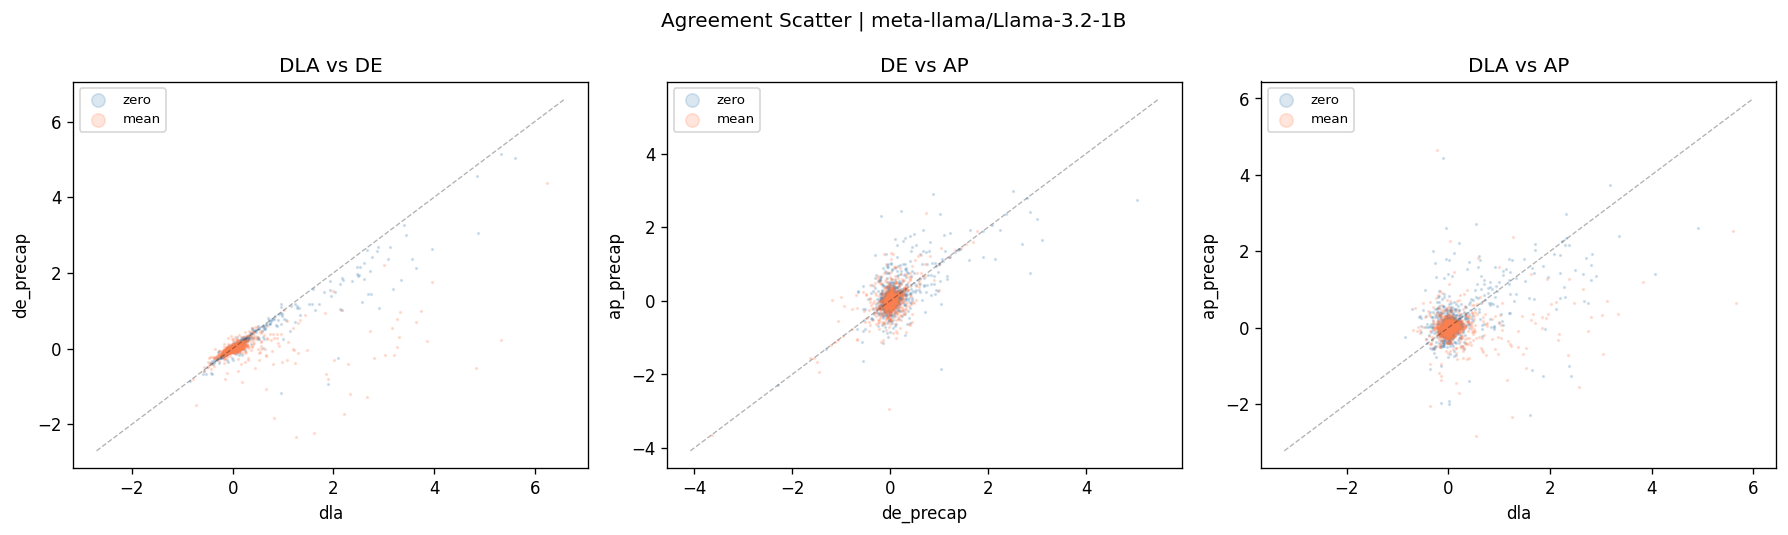

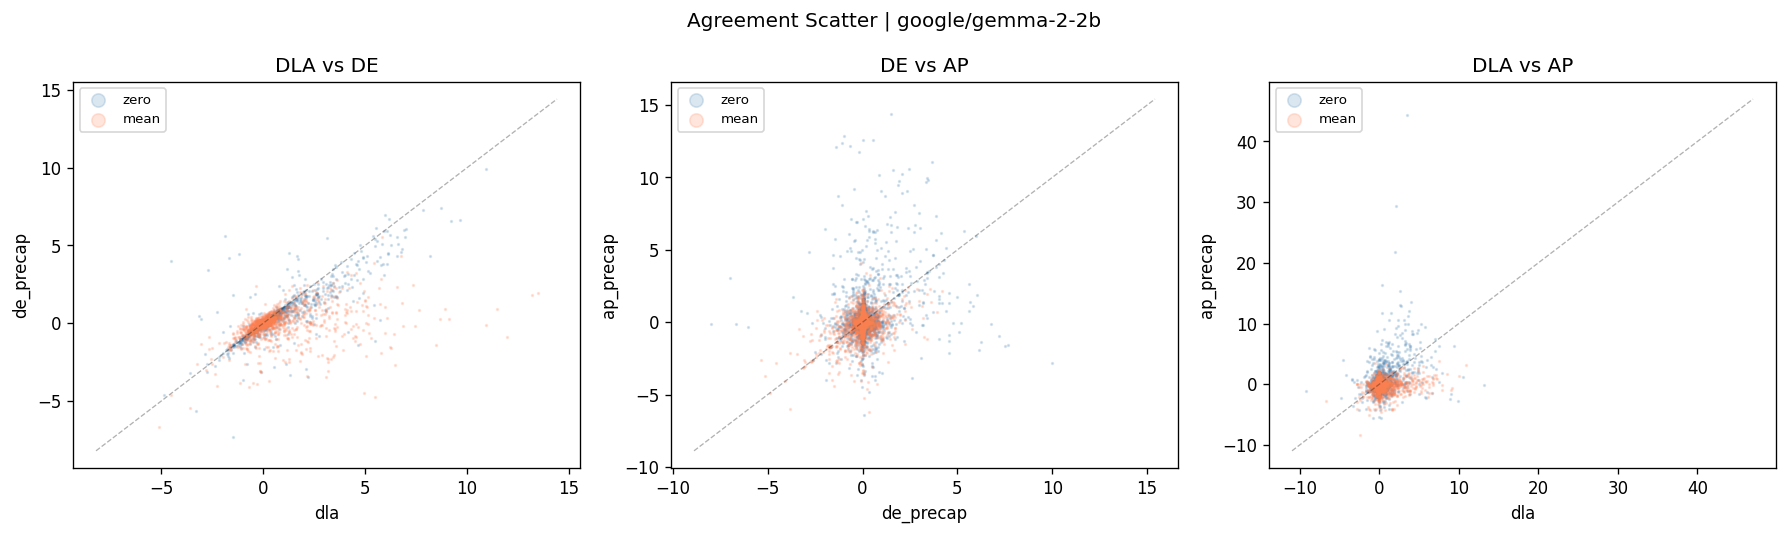

In [10]:
SCATTER_N = 10_000
rng = np.random.RandomState(42)

pairs = [
    ("dla", "de_precap", "DLA vs DE"),
    ("de_precap", "ap_precap", "DE vs AP"),
    ("dla", "ap_precap", "DLA vs AP"),
]

for model in MODELS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for col_idx, (xcol, ycol, title) in enumerate(pairs):
        ax = axes[col_idx]
        for mode, color in [("zero", "steelblue"), ("mean", "coral")]:
            key = (model, mode)
            if key not in record_dfs:
                continue
            df = record_dfs[key]
            if len(df) > SCATTER_N:
                idx_s = rng.choice(len(df), SCATTER_N, replace=False)
                sub = df.iloc[idx_s]
            else:
                sub = df
            ax.scatter(sub[xcol], sub[ycol], s=1, alpha=0.2,
                       c=color, label=mode)
        lims = [ax.get_xlim(), ax.get_ylim()]
        lo = min(lims[0][0], lims[1][0])
        hi = max(lims[0][1], lims[1][1])
        ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3, lw=0.8)
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title(title)
        ax.legend(fontsize=8, markerscale=8)
    fig.suptitle(f"Agreement Scatter | {model}", fontsize=12)
    plt.tight_layout()
    plt.show()

## 10. Error Distribution

Histograms of |DLA - DE| and |DE - AP| (log-scaled x-axis).

In [ ]:
for model in MODELS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for mode, color, alpha in [("zero", "steelblue", 0.6),
                                ("mean", "coral", 0.5)]:
        key = (model, mode)
        if key not in record_dfs:
            continue
        df = record_dfs[key]
        err_a = np.abs(df["dla"].values - df["de_precap"].values)
        err_b = np.abs(df["de_precap"].values - df["ap_precap"].values)
        for ax_idx, (err, label) in enumerate([
            (err_a, "|DLA - DE|"), (err_b, "|DE - AP|")
        ]):
            ax = axes[ax_idx]
            err_pos = err[err > 0]
            if len(err_pos):
                ax.hist(np.log10(err_pos), bins=80, alpha=alpha,
                        label=mode, density=True, color=color)
            ax.set_xlabel(f"log10({label})")
            ax.set_ylabel("Density")
            ax.set_title(f"{label} Distribution")
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
    fig.suptitle(f"Error Distribution | {model}", fontsize=12)
    plt.tight_layout()
    plt.show()

## 11. Top 20 Divergent Components (zero ablation)

Records with the largest |DLA - AP| for qualitative inspection.

In [11]:
for model in MODELS:
    key = (model, "zero")
    if key not in record_dfs:
        continue
    df = record_dfs[key].copy()
    df["abs_error"] = (df["dla"] - df["ap_precap"]).abs()
    top = df.nlargest(20, "abs_error")
    display_cols = ["example_id", "candidate", "layer",
                    "component_type", "head_idx",
                    "dla", "de_precap", "ap_precap", "abs_error"]
    print()
    print("=" * 80)
    print(f"Top 20 Divergent Components: {model} (zero ablation)")
    print("=" * 80)
    display(top[display_cols].reset_index(drop=True))


Top 20 Divergent Components: gpt2-xl (zero ablation)


,example_id,candidate,layer,component_type,head_idx,dla,de_precap,ap_precap,abs_error
0,1d0021db9bc4de64b3dd2ff4b056a4ca,dolls,0,mlp,-1,0.095073,-0.013695,13.003926,12.908853
1,a80556f1d85f6663b5227685cdf48f24,nervous,0,mlp,-1,0.227005,0.124296,12.105628,11.878623
2,6959414713223f10a751d8629c848b5e,angry,0,mlp,-1,0.261298,0.045013,11.743475,11.482177
3,f433eb42395fe8f382b1e81e3c6973ac,evil,0,mlp,-1,0.005009,-0.153524,11.018323,11.013314
4,1d0021db9bc4de64b3dd2ff4b056a4ca,trucks,0,mlp,-1,0.033367,-0.060946,10.597814,10.564447
5,ca49137ed26c4d52fcf0f86499cc25d1,strict,0,mlp,-1,0.166007,-0.000243,10.443704,10.277697
6,57cefe9835759a22b6f682a03eceeb11,lazy,0,mlp,-1,0.089485,-0.070497,10.366760,10.277275
7,d2ea148c7198ef6dd7970d8ae9cef77b,sedan,0,mlp,-1,0.177256,0.062313,10.351124,10.173867
8,d2ea148c7198ef6dd7970d8ae9cef77b,truck,0,mlp,-1,0.066219,-0.053263,9.971948,9.905728
9,1088230a89ca7633a791add97ec93b71,love,0,mlp,-1,0.026103,-0.072463,9.752913,9.726811



Top 20 Divergent Components: meta-llama/Llama-3.2-1B (zero ablation)


,example_id,candidate,layer,component_type,head_idx,dla,de_precap,ap_precap,abs_error
0,9ad66381ed8e357057ef435f79dd0e7e,handsome,0,mlp,-1,-0.028380,-0.054188,5.976368,6.004748
1,2bd010e1c8b7df82619641c53f48a99e,nurturing,0,mlp,-1,-0.259042,-0.273359,5.722008,5.981050
2,2bd010e1c8b7df82619641c53f48a99e,evil,0,mlp,-1,0.025651,0.006426,5.158978,5.133326
3,781b8a87fd54fd52a75909fc742d1189,pretty,0,mlp,-1,-0.032294,-0.053067,4.727364,4.759657
4,3ab3cd6b91705780ac6435cb7bb0a105,truck,0,mlp,-1,-0.108974,-0.142170,4.441336,4.550309
5,882e56833e2059bae24f2d0b4353ebc0,stressed,1,mlp,-1,-0.220615,-0.221095,4.292293,4.512907
6,9ad66381ed8e357057ef435f79dd0e7e,rich,0,mlp,-1,-0.101633,-0.124646,3.840590,3.942224
7,3b56b999c5e07c010e5769fdfc3d5937,old,14,mlp,-1,2.879070,2.549123,-1.056104,3.935174
8,5456f782bcd3ab9dc7f859aafacfc555,leader,15,mlp,-1,3.814005,-0.099576,-0.099562,3.913566
9,164007e8e262ec378f61f05178071870,stern,0,mlp,-1,-0.003434,0.004313,3.894600,3.898034



Top 20 Divergent Components: google/gemma-2-2b (zero ablation)


,example_id,candidate,layer,component_type,head_idx,dla,de_precap,ap_precap,abs_error
0,27501e2be0f0ff6b71fe899eb5f86f0d,married,18,mlp,-1,3.516253,2.604725,44.352650,40.836396
1,27501e2be0f0ff6b71fe899eb5f86f0d,separated,18,mlp,-1,0.518979,-0.079336,34.274441,33.755461
2,ec824c96bd49dfb713362a6f92c973c8,articulate,18,mlp,-1,0.762177,0.550270,34.427132,33.664955
3,a80556f1d85f6663b5227685cdf48f24,nervous,18,mlp,-1,6.557005,5.543362,38.501404,31.944399
4,ec824c96bd49dfb713362a6f92c973c8,annoying,18,mlp,-1,-1.382533,-1.545265,27.158447,28.540980
5,a80556f1d85f6663b5227685cdf48f24,sad,18,mlp,-1,2.071556,1.206188,29.450500,27.378945
6,4cab927ef3fad167ffb17b4b937485f1,a band,18,mlp,-1,2.514722,1.636959,26.836952,24.322230
7,9aa148575797c7fd2d4265872318ea12,stable,18,mlp,-1,1.086646,0.604230,23.330734,22.244088
8,9aa148575797c7fd2d4265872318ea12,moody,18,mlp,-1,1.386737,0.880133,23.578167,22.191430
9,ec824c96bd49dfb713362a6f92c973c8,mouse,18,mlp,-1,1.967036,1.894151,21.838001,19.870965


## Conclusions

### 1. Source A (Frozen-Norm Error) — DLA's Linear Approximation

| Model | Zero NMAE | Mean NMAE |
|-------|-----------|-----------|
| GPT-2 XL | ~42% | ~77% |
| Llama-3.2-1B | ~17% | ~90% |
| Gemma-2-2B | ~15% | ~68% |

- **Zero-ablation**: Newer architectures (Llama, Gemma) have much lower Source A
  (~15–17%) than GPT-2 XL (~42%). GPT-2's LayerNorm includes mean subtraction,
  which amplifies per-component scale mismatches.
- **Mean-ablation**: Source A balloons to 68–90% because the closed-form identity
  `DE = clean*(1−ρ) + ρ*DLA` only holds for zero-baseline DE.
- **Identity verified**: Max residual < 1×10⁻⁵ for zero-ablation across all models,
  confirming the identity holds to machine precision.

### 2. Source B (Indirect Effects) — The Dominant Error

- Source B is **~95–105%** across all models and both ablation modes — the dominant
  error source by far.
- DE captures only a component's *direct* logit-space contribution. AP also captures
  *indirect* effects (how removal changes downstream layer computations).
- **Mean-ablation did NOT substantially reduce Source B**, disproving the hypothesis
  that zero-ablation's out-of-distribution inputs inflate indirect effects. The
  indirect effects are genuine signal.

### 3. Total Error

- **Zero-ablation**: ~101–111% total NMAE. DLA captures roughly half the true causal
  effect with correct sign and magnitude.
- **Mean-ablation**: ~135–150%. Worse overall: Source A inflates without meaningful
  Source B reduction.
- **Zero-ablation is the more informative comparison** for understanding DLA's
  limitations.

### 4. Selection Quality — DLA Cannot Reliably Select Components

| Model (zero) | Spearman ρ | Sign agreement | Top-5 Jaccard |
|-------------|-----------|---------------|--------------|
| GPT-2 XL | 0.31 | 63% | 0.11 |
| Llama-3.2-1B | 0.20 | 57% | 0.43 |
| Gemma-2-2B | 0.12 | 54% | 0.11 |

- Ranking correlation is weak (Spearman 0.1–0.3).
- Sign agreement barely exceeds chance (50%).
- **Top-5 components identified by DLA vs AP rarely overlap** (Jaccard 0.0–0.43).
- **Critical finding**: DLA should not be used for component selection in bias
  mitigation. Activation patching is necessary despite higher compute cost.

### 5. Soft-Cap Distortion (Gemma-2)

- `tanh(logits/30)` adds ~34–38% distortion to both DE and AP.
- Pre-cap DLA scores are more reliable for Gemma-2. Post-cap values should be
  avoided for component ranking.

### 6. Practical Implications for Bias Mitigation

- DLA is useful as a **cheap qualitative signal** for understanding which
  layers/regions contribute to biased predictions.
- For **quantitative component selection** (e.g., choosing which heads to ablate
  for debiasing), DLA's ranking errors are too large. Activation patching should
  be used.
- The ~13–14% multi-token candidate rate is a minor noise source but not a
  fundamental limitation.
- The ρ distribution shows most components have ρ ≈ 1 (near-unit norm change),
  with a heavy tail that drives Source A error — these outlier components are
  where DLA diverges most from the true direct effect.